# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

class Card:
    # all possible suits and values for a standard deck
    suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
    values = [2, 3, 4, 5, 6, 7, 8, 9, 10, "Jack", "Queen", "King", "Ace"]
    
    def __init__(self, suit, value):
        # private so once a card is made it cant be changed
        self.__suit = suit
        self.__value = value
        self.__is_shuffle = False
    
    # accessors
    def suit(self):
        return self.__suit
    
    def value(self):
        return self.__value
    
    def numerical_value(self):
        # face cards are 10, ace is 1 for now (we handle 11 in hand_value)
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack", "Queen", "King"]:
            return 10
        else:
            return self.__value
    
    def is_shuffle_card(self):
        return self.__is_shuffle
    
    def set_shuffle(self):
        self.__is_shuffle = True
    
    def __str__(self):
        if self.__is_shuffle:
            return "Shuffle Card"
        return str(self.__value) + " of " + self.__suit


class Deck:
    def __init__(self, num_decks=6):
        self.__cards = list()
        self.__num_decks = num_decks
        self.__needs_shuffle = False
        
        # casinos use multiple decks to make card counting harder
        for i in range(num_decks):
            self.__add_deck()
        
        # add the plastic card that tells us when to reshuffle
        plastic = Card("None", 0)
        plastic.set_shuffle()
        self.__cards.append(plastic)
    
    def __add_deck(self):
        # same logic as lecture 12 quiz make_deck but using Card objects instead of tuples
        for suit in Card.suits:
            for value in Card.values:
                self.__cards.append(Card(suit, value))
    
    def shuffle(self):
        random.shuffle(self.__cards)
        self.__needs_shuffle = False
    
    def deal(self):
        # if we need to shuffle or ran out of cards, rebuild everything
        if len(self.__cards) == 0 or self.__needs_shuffle:
            self.__cards = list()
            for i in range(self.__num_decks):
                self.__add_deck()
            plastic = Card("None", 0)
            plastic.set_shuffle()
            self.__cards.append(plastic)
            self.shuffle()
        
        card = self.__cards.pop()
        
        # if we hit the plastic card, flag for reshuffle and give a real card
        if card.is_shuffle_card():
            self.__needs_shuffle = True
            # edge case: plastic card was the very last card
            if len(self.__cards) == 0:
                self.__cards = list()
                for i in range(self.__num_decks):
                    self.__add_deck()
                plastic = Card("None", 0)
                plastic.set_shuffle()
                self.__cards.append(plastic)
                self.shuffle()
            card = self.__cards.pop()
        
        return card

# mapping a function that asks each one for the numerical value and then run the sum
def hand_value(hand):
    # sum up all card values with aces counted as 1
    total = sum(map(lambda c: c.numerical_value(), hand))
    
    # count how many aces we have
    n_aces = 0
    for c in hand:
        if c.value() == "Ace":
            n_aces = n_aces + 1
    
    # if no aces just return total
    if n_aces == 0:
        return total
    
    # counting one ace as 11 instead of 1 (adding 10 since we already counted it as 1)
    if total + 10 <= 21:
        return total + 10
    return total

In [2]:
# testing
my_deck = Deck(6)
my_deck.shuffle()

print("Dealing 10 cards:")
for i in range(10):
    print(my_deck.deal())

# testing hand_value with aces
print()
h1 = [Card("Hearts", 10), Card("Hearts", "Ace")]
print([str(c) for c in h1], "=", hand_value(h1))  # should be 21

h2 = [Card("Hearts", 10), Card("Spades", 5), Card("Clubs", "Ace")]
print([str(c) for c in h2], "=", hand_value(h2))  # should be 16

h3 = [Card("Diamonds", 3), Card("Clubs", 10)]
print([str(c) for c in h3], "=", hand_value(h3))  # should be 13

Dealing 10 cards:
3 of Spades
5 of Diamonds
2 of Diamonds
King of Hearts
3 of Hearts
9 of Diamonds
Queen of Diamonds
10 of Spades
9 of Spades
5 of Spades

['10 of Hearts', 'Ace of Hearts'] = 21
['10 of Hearts', '5 of Spades', 'Ace of Clubs'] = 16
['3 of Diamonds', '10 of Clubs'] = 13


2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [3]:
class Player:
    # base player class : every type of player will inherit from this
    
    def __init__(self, name, chips=100):
        self.__name = name
        self.__chips = chips
        self.__hand = list()   # list of Card objects for current round
    
    def name(self):
        pass
    
    def chips(self):
        pass
    
    def hand(self):
        pass
    
    # chip management
    def pay(self, amount):
        # give chips to the player (they won)
        pass
    
    def charge(self, amount):
        # take chips from the player (they lost)
        pass
    
    # hand management
    def add_card(self, card):
        # dealer gives a card to this player
        pass
    
    def reset_hand(self):
        # clear hand for new round
        pass
    
    # the big one : each player type will override this with their own strategy
    def play_hand(self, up_cards, down_card, seen_cards):
        # returns True to hit, False to stay
        pass


class DealerPlayer(Player):
    # plays like a casino dealer : hit on 16, stay on 17
    
    def __init__(self):
        Player.__init__(self, "Dealer", 10000)
        self.__threshold = 17
    
    def play_hand(self, up_cards, down_card, seen_cards):
        pass


class AlwaysHitPlayer(Player):
    # dumb player that always hits no matter what
    
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
    
    def play_hand(self, up_cards, down_card, seen_cards):
        pass


class ConsolePlayer(Player):
    # human player : asks for input from keyboard
    
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
    
    def play_hand(self, up_cards, down_card, seen_cards):
        pass


class Game:
    # holds the deck, players, and runs rounds of blackjack
    
    def __init__(self, num_decks=6):
        self.__deck = Deck(num_decks)
        self.__players = list()      # regular players
        self.__dealer = None         # the dealer
        self.__seen_cards = list()   # all cards everyone has seen
    
    def add_player(self, player):
        # add a player to the game
        pass
    
    def play_round(self):
        # play one round of blackjack
        # deal 2 cards to everyone, let them hit/stay, figure out who won
        pass
    
    def play_game(self, n_rounds):
        # play multiple rounds
        pass
    
    def status(self):
        # print how many chips each player has
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [4]:
class Player:
    def __init__(self, name, chips=100):
        self.__name = name
        self.__chips = chips
        self.__hand = list()
    
    def name(self):
        return self.__name
    
    def chips(self):
        return self.__chips
    
    def hand(self):
        return self.__hand
    
    def pay(self, amount):
        # player won, give them chips
        self.__chips = self.__chips + amount
    
    def charge(self, amount):
        # player lost, take chips
        self.__chips = self.__chips - amount
    
    def add_card(self, card):
        self.__hand.append(card)
    
    def reset_hand(self):
        self.__hand = list()
    
    def play_hand(self, up_cards, down_card, seen_cards):
        # base class doesn't know how to play, children will override this
        raise NotImplementedError


class DealerPlayer(Player):
    # casino dealer always hits below 17, stays on 17 or above
    def __init__(self):
        Player.__init__(self, "Dealer", 10000)
        self.__threshold = 17
    
    def play_hand(self, up_cards, down_card, seen_cards):
        # dealer looks at their full hand (down card and up cards)
        full_hand = [down_card] + up_cards
        val = hand_value(full_hand)
        # hit if below threshold, stay otherwise
        if val < self.__threshold:
            return True
        return False


class ConsolePlayer(Player):
    # human player, asks for keyboard input
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
    
    def play_hand(self, up_cards, down_card, seen_cards):
        # show the player their cards
        full_hand = [down_card] + up_cards
        print("Your hand:", [str(c) for c in full_hand], "Value:", hand_value(full_hand))
        print("Cards seen so far:", [str(c) for c in seen_cards])
        
        answer = input("Hit? (y/n): ")
        if answer.lower() == "y":
            return True
        return False


class Game:
    def __init__(self, num_decks=6, verbose=True):
        self.__deck = Deck(num_decks)
        self.__deck.shuffle()
        self.__players = list()
        self.__dealer = DealerPlayer()
        self.__verbose = verbose
    
    def add_player(self, player):
        self.__players.append(player)
    
    def status(self):
        for p in self.__players:
            print(p.name(), ":", p.chips(), "chips")
        print(self.__dealer.name(), ":", self.__dealer.chips(), "chips")
    
    def play_round(self):
        seen_cards = list()
        
        # everybody gets a fresh hand
        for p in self.__players:
            p.reset_hand()
        self.__dealer.reset_hand()
        
        # all players including dealer in one list for dealing
        all_players = self.__players + [self.__dealer]
        
        # deal first card to everyone (this is the down card, face down)
        for p in all_players:
            card = self.__deck.deal()
            p.add_card(card)
        
        # deal second card to everyone (this is the up card, visible)
        for p in all_players:
            card = self.__deck.deal()
            p.add_card(card)
            # everyone can see the up cards
            seen_cards.append(card)
        
        # each player takes their turn
        for p in all_players:
            hand = p.hand()
            down_card = hand[0]
            up_cards = hand[1:]
            
            # keep asking until they stay or bust
            hit = True
            while hit:
                hit = p.play_hand(up_cards, down_card, seen_cards)
                if hit:
                    new_card = self.__deck.deal()
                    p.add_card(new_card)
                    up_cards.append(new_card)
                    seen_cards.append(new_card)
                    
                    # check if they busted
                    if hand_value(p.hand()) > 21:
                        if self.__verbose:
                            print(p.name(), "busted with", hand_value(p.hand()))
                        hit = False
        
        # figure out who won
        dealer_val = hand_value(self.__dealer.hand())
        dealer_busted = dealer_val > 21
        
        if self.__verbose:
            print("Dealer has:", dealer_val)
        
        for p in self.__players:
            player_val = hand_value(p.hand())
            player_busted = player_val > 21
            
            if player_busted:
                # player busted, they lose no matter what
                p.charge(2)
                self.__dealer.pay(2)
                if self.__verbose:
                    print(p.name(), "busted. Lost 2 chips.")
            
            elif dealer_busted:
                # dealer busted but player didnt
                if player_val == 21:
                    p.pay(3)
                    self.__dealer.charge(3)
                    if self.__verbose:
                        print(p.name(), "got 21! Won 3 chips.")
                else:
                    p.pay(2)
                    self.__dealer.charge(2)
                    if self.__verbose:
                        print(p.name(), "won 2 chips. Dealer busted.")
            
            elif dealer_val == 21:
                # dealer got 21
                if player_val == 21:
                    # push, nobody wins
                    if self.__verbose:
                        print(p.name(), "push. Both got 21.")
                else:
                    p.charge(2)
                    self.__dealer.pay(2)
                    if self.__verbose:
                        print(p.name(), "lost 2 chips. Dealer got 21.")
            
            else:
                # nobody busted, nobody got 21, compare values
                if player_val > dealer_val:
                    p.pay(2)
                    self.__dealer.charge(2)
                    if self.__verbose:
                        print(p.name(), "won 2 chips.", player_val, "vs", dealer_val)
                elif player_val < dealer_val:
                    p.charge(2)
                    self.__dealer.pay(2)
                    if self.__verbose:
                        print(p.name(), "lost 2 chips.", player_val, "vs", dealer_val)
                else:
                    if self.__verbose:
                        print(p.name(), "push.", player_val, "vs", dealer_val)
    
    def play_game(self, n_rounds):
        for i in range(n_rounds):
            if self.__verbose:
                print("--- Round", i+1, "---")
            self.play_round()
        if self.__verbose:
            self.status()

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [5]:
# we need an AlwaysHitPlayer from our skeleton
class AlwaysHitPlayer(Player):
    # dumb player that always hits no matter what
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
    
    def play_hand(self, up_cards, down_card, seen_cards):
        return True

#  a simple player that plays like the dealer (hits below some threshold)
class SimplePlayer(Player):
    def __init__(self, name, chips=100, threshold=17):
        Player.__init__(self, name, chips)
        self.__threshold = threshold
    
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        if hand_value(full_hand) < self.__threshold:
            return True
        return False

In [6]:
# test game with a dummy always-hit player and 2 dealer-like players
game = Game(verbose=True)
game.add_player(AlwaysHitPlayer("AlwaysHit", 100))
game.add_player(SimplePlayer("Player1", 100, 17))
game.add_player(SimplePlayer("Player2", 100, 15))

game.play_game(5)

--- Round 1 ---
AlwaysHit busted with 28
Player2 busted with 22
Dealer has: 18
AlwaysHit busted. Lost 2 chips.
Player1 lost 2 chips. 17 vs 18
Player2 busted. Lost 2 chips.
--- Round 2 ---
AlwaysHit busted with 23
Player1 busted with 23
Dealer busted with 25
Dealer has: 25
AlwaysHit busted. Lost 2 chips.
Player1 busted. Lost 2 chips.
Player2 won 2 chips. Dealer busted.
--- Round 3 ---
AlwaysHit busted with 22
Player2 busted with 22
Dealer has: 21
AlwaysHit busted. Lost 2 chips.
Player1 lost 2 chips. Dealer got 21.
Player2 busted. Lost 2 chips.
--- Round 4 ---
AlwaysHit busted with 30
Player2 busted with 22
Dealer has: 17
AlwaysHit busted. Lost 2 chips.
Player1 won 2 chips. 18 vs 17
Player2 busted. Lost 2 chips.
--- Round 5 ---
AlwaysHit busted with 26
Dealer has: 18
AlwaysHit busted. Lost 2 chips.
Player1 push. 18 vs 18
Player2 lost 2 chips. 15 vs 18
AlwaysHit : 90 chips
Player1 : 96 chips
Player2 : 94 chips
Dealer : 10020 chips


In [7]:
# run a bigger game with verbose off to just see chip totals
game2 = Game(verbose=False)
game2.add_player(AlwaysHitPlayer("AlwaysHit", 100))
game2.add_player(SimplePlayer("DealerStyle", 100, 17))
game2.add_player(SimplePlayer("Conservative", 100, 15))

game2.play_game(20)
print("After 20 rounds:")
game2.status()

After 20 rounds:
AlwaysHit : 60 chips
DealerStyle : 98 chips
Conservative : 96 chips
Dealer : 10046 chips


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [8]:
# we keep a running count of all cards youve seen , if lots of low cards have been played (count is positive), 
# that means more high cards are left in the deck which is good for the player
# if count is negative, more low cards are left so you hit.

class CardCountPlayer(Player):
    def __init__(self, name, chips=100, threshold=0):
        Player.__init__(self, name, chips)
        # threshold controls how aggressive the player is
        # hit if count < threshold, stay otherwise
        self.__threshold = threshold
    
    def count_cards(self, seen_cards):
        # go through all the cards weve seen and add up the count
        count = 0
        for card in seen_cards:
            val = card.numerical_value()
            if val >= 2 and val <= 6:
                count = count + 1
            elif val >= 7 and val <= 9:
                count = count + 0
            else:
                # 10, Jack, Queen, King, Ace are all -1
                count = count - 1
        return count
    
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        val = hand_value(full_hand)
        
        # if we have 21 or close, no reason to hit
        if val >= 21:
            return False
        
        # if hand is really low always hit regardless of count
        if val < 12:
            return True
        
        # use the card counting to decide
        count = self.count_cards(seen_cards)
        if count < self.__threshold:
            return True
        return False                  

In [9]:
#test
game3 = Game(verbose=False)
game3.add_player(CardCountPlayer("Counter", 100, threshold=0))
game3.add_player(SimplePlayer("DealerStyle", 100, 17))

game3.play_game(20)
print("After 20 rounds:")
game3.status()

After 20 rounds:
Counter : 92 chips
DealerStyle : 94 chips
Dealer : 10014 chips


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [10]:
# 1 card counting player + 3 dealer-strategy players
# everyone starts with 100 chips, play 50 rounds
# verbose is off to prevent unnecessary flooding

game7 = Game(verbose=False)

counter = CardCountPlayer("Counter", 100, threshold=0)
player1 = SimplePlayer("DealerStyle1", 100, 17)
player2 = SimplePlayer("DealerStyle2", 100, 17)
player3 = SimplePlayer("DealerStyle3", 100, 17)

game7.add_player(counter)
game7.add_player(player1)
game7.add_player(player2)
game7.add_player(player3)

game7.play_game(50)

print("After 50 rounds:")
game7.status()
print()

# compute winnings (chips at end minus what they started with)
starting_chips = 100
winnings = counter.chips() - starting_chips
print("Counter started with:", starting_chips)
print("Counter ended with:", counter.chips())
print("Counter winnings:", winnings)
print("Winnings per round:", winnings / 50.0)

After 50 rounds:
Counter : 65 chips
DealerStyle1 : 99 chips
DealerStyle2 : 82 chips
DealerStyle3 : 84 chips
Dealer : 10070 chips

Counter started with: 100
Counter ended with: 65
Counter winnings: -35
Winnings per round: -0.7


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


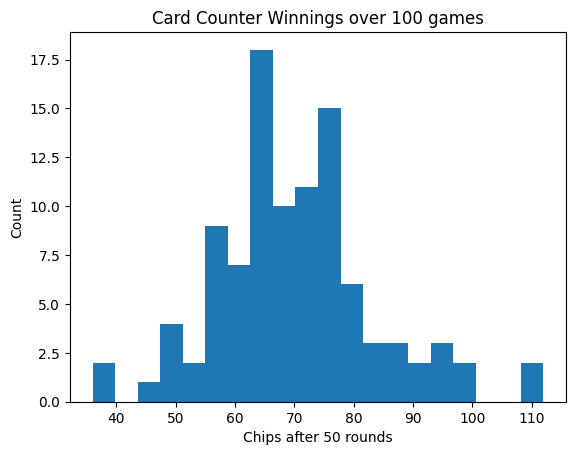

Mean chips at end: 69.97
Std of chips: 13.38391198416965
Mean winnings: -30.03
Average winnings per round: -0.6006

Probability of net winning: 0.02
Probability of net losing: 0.98
Probability of breaking even: 0.0


In [11]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

starting_chips = 100
n_games = 100
n_rounds = 50

winnings_list = list()

for i in range(n_games):
    # make a fresh game each time
    game8 = Game(verbose=False)
    
    counter = CardCountPlayer("Counter", starting_chips, threshold=0)
    game8.add_player(counter)
    game8.add_player(SimplePlayer("DealerStyle1", starting_chips, 17))
    game8.add_player(SimplePlayer("DealerStyle2", starting_chips, 17))
    game8.add_player(SimplePlayer("DealerStyle3", starting_chips, 17))
    
    game8.play_game(n_rounds)
    
    # store the counter's final chips
    winnings_list.append(counter.chips())

# histogram
plt.hist(winnings_list, bins=20)
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Count")
plt.title("Card Counter Winnings over 100 games")
plt.show()

# stats
mean_chips = np.mean(winnings_list)
std_chips = np.std(winnings_list)
mean_winnings = mean_chips - starting_chips
winnings_per_round = mean_winnings / n_rounds

print("Mean chips at end:", mean_chips)
print("Std of chips:", std_chips)
print("Mean winnings:", mean_winnings)
print("Average winnings per round:", winnings_per_round)

# probability of net winning vs losing
n_won = 0
n_lost = 0
for w in winnings_list:
    if w > starting_chips:
        n_won = n_won + 1
    elif w < starting_chips:
        n_lost = n_lost + 1

print()
print("Probability of net winning:", n_won / float(n_games))
print("Probability of net losing:", n_lost / float(n_games))
print("Probability of breaking even:", (n_games - n_won - n_lost) / float(n_games))

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

Threshold: -4 Mean chips: 89.18 Std: 12.5 Winnings/round: -0.2164
Threshold: -2 Mean chips: 84.6 Std: 14.19 Winnings/round: -0.308
Threshold: 0 Mean chips: 72.4 Std: 13.95 Winnings/round: -0.552
Threshold: 2 Mean chips: 52.18 Std: 12.61 Winnings/round: -0.9564
Threshold: 4 Mean chips: 38.35 Std: 9.88 Winnings/round: -1.233


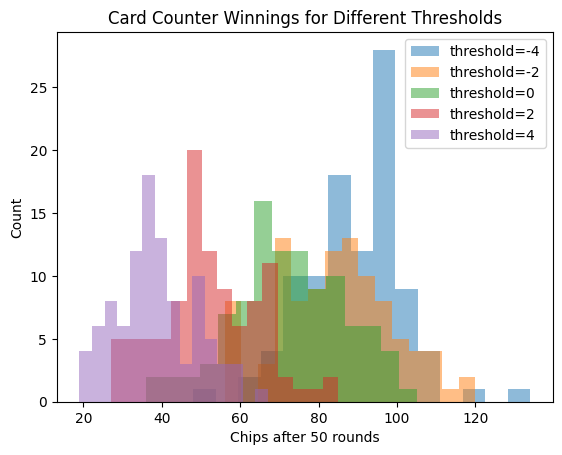

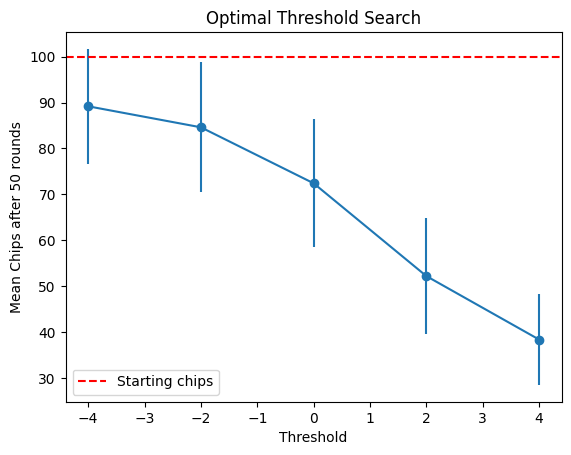

Best threshold: -4 with mean chips: 89.18


In [12]:
# Q9 - Scanning different threshold values
# trying at least 5 different thresholds to see which one works best
# teacher showed the same idea - scan a parameter and compare with error bars

import numpy as np
import matplotlib.pyplot as plt

starting_chips = 100
n_games = 100
n_rounds = 50

thresholds = [-4, -2, 0, 2, 4]

# store means and stds so we can make the errorbar plot after
mean_results = list()
std_results = list()

for thresh in thresholds:
    winnings_list = list()
    
    for i in range(n_games):
        game9 = Game(verbose=False)
        counter = CardCountPlayer("Counter", starting_chips, threshold=thresh)
        game9.add_player(counter)
        game9.add_player(SimplePlayer("DealerStyle1", starting_chips, 17))
        game9.add_player(SimplePlayer("DealerStyle2", starting_chips, 17))
        game9.add_player(SimplePlayer("DealerStyle3", starting_chips, 17))
        game9.play_game(n_rounds)
        winnings_list.append(counter.chips())
    
    mean_val = np.mean(winnings_list)
    std_val = np.std(winnings_list)
    mean_results.append(mean_val)
    std_results.append(std_val)
    
    print("Threshold:", thresh,
          "Mean chips:", round(mean_val, 2),
          "Std:", round(std_val, 2),
          "Winnings/round:", round((mean_val - starting_chips) / n_rounds, 4))
    
    # add each threshold to the histogram in the same loop so we dont run games twice
    plt.hist(winnings_list, bins=15, alpha=0.5, label="threshold=" + str(thresh))

plt.xlabel("Chips after 50 rounds")
plt.ylabel("Count")
plt.title("Card Counter Winnings for Different Thresholds")
plt.legend()
plt.show()

# errorbar plot like teacher showed in the lecture
# "here I'm applying the mean and standard deviation as the error bars"
plt.errorbar(thresholds, mean_results, yerr=std_results, fmt='o-')
plt.xlabel("Threshold")
plt.ylabel("Mean Chips after 50 rounds")
plt.title("Optimal Threshold Search")
plt.axhline(y=starting_chips, color='r', linestyle='--', label="Starting chips")
plt.legend()
plt.show()

# find the best threshold
best_index = np.argmax(mean_results)
print("Best threshold:", thresholds[best_index], "with mean chips:", round(mean_results[best_index], 2))

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [13]:
# Basic Strategy - instead of just counting cards, we also look at what the dealer is showing
# The idea is: if the dealer shows a low card (2-6), they are more likely to bust
# so we can afford to stay on lower hands and let them bust
# But if the dealer shows a high card (7-Ace), we need to be more aggressive and hit more
# This is a well known blackjack strategy

class BasicStrategyPlayer(Player):
    def __init__(self, name, chips=100):
        Player.__init__(self, name, chips)
    
    def play_hand(self, up_cards, down_card, seen_cards):
        full_hand = [down_card] + up_cards
        val = hand_value(full_hand)
        
        # always stay on 17 or above
        if val >= 17:
            return False
        
        # always hit on 11 or below, cant bust
        if val <= 11:
            return True
        
        # for 12-16 it depends on what the dealer is showing
        # the dealers up card is the last card in seen_cards for the dealer
        # but we dont know which one is the dealers exactly
        # so we just look at the last card dealt as an estimate of the dealers visible card
        # in a real game you can see the dealers up card
        
        # look at the dealers up card - its the last one in seen_cards 
        # (dealer is dealt last in our game)
        if len(seen_cards) > 0:
            dealer_up = seen_cards[-1]
            dealer_val = dealer_up.numerical_value()
            
            # dealer shows 2-6: they are likely to bust, so we stay on 12+
            if dealer_val >= 2 and dealer_val <= 6:
                return False
            
            # dealer shows 7-Ace: they probably have a good hand, we need to hit
            else:
                return True
        
        # fallback: just hit if under 17
        if val < 17:
            return True
        return False

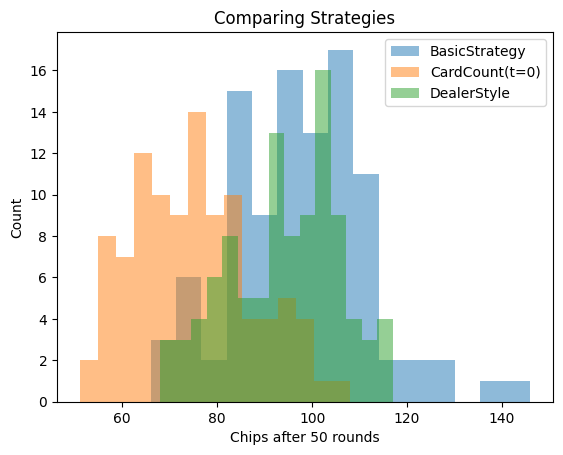

Strategy Comparison after 50 rounds ( 100 games ):

BasicStrategy
  Mean chips: 97.44
  Std: 14.33
  Winnings/round: -0.0512
  P(win): 0.44
  P(lose): 0.54

CardCount(t=0)
  Mean chips: 74.52
  Std: 12.62
  Winnings/round: -0.5096
  P(win): 0.02
  P(lose): 0.98

DealerStyle
  Mean chips: 94.37
  Std: 11.71
  Winnings/round: -0.1126
  P(win): 0.36
  P(lose): 0.62



In [14]:
# compare the new strategy vs card counting vs dealer style
# run 100 games of 50 rounds for each

import numpy as np
import matplotlib.pyplot as plt

starting_chips = 100
n_games = 100
n_rounds = 50

strategies = {
    "BasicStrategy": [],
    "CardCount(t=0)": [],
    "DealerStyle": []
}

for i in range(n_games):
    # make one game with all three players so they play in same conditions
    game10 = Game(verbose=False)
    
    basic = BasicStrategyPlayer("BasicStrategy", starting_chips)
    counter = CardCountPlayer("CardCount(t=0)", starting_chips, threshold=0)
    dealer_style = SimplePlayer("DealerStyle", starting_chips, 17)
    
    game10.add_player(basic)
    game10.add_player(counter)
    game10.add_player(dealer_style)
    
    game10.play_game(n_rounds)
    
    strategies["BasicStrategy"].append(basic.chips())
    strategies["CardCount(t=0)"].append(counter.chips())
    strategies["DealerStyle"].append(dealer_style.chips())

# histogram all three
for name, results in strategies.items():
    plt.hist(results, bins=15, alpha=0.5, label=name)
plt.xlabel("Chips after 50 rounds")
plt.ylabel("Count")
plt.title("Comparing Strategies")
plt.legend()
plt.show()

# print stats for each
print("Strategy Comparison after", n_rounds, "rounds (", n_games, "games ):")
print()
for name, results in strategies.items():
    mean_val = np.mean(results)
    std_val = np.std(results)
    wins = sum(1 for r in results if r > starting_chips)
    losses = sum(1 for r in results if r < starting_chips)
    print(name)
    print("  Mean chips:", round(mean_val, 2))
    print("  Std:", round(std_val, 2))
    print("  Winnings/round:", round((mean_val - starting_chips) / n_rounds, 4))
    print("  P(win):", wins / float(n_games))
    print("  P(lose):", losses / float(n_games))
    print()

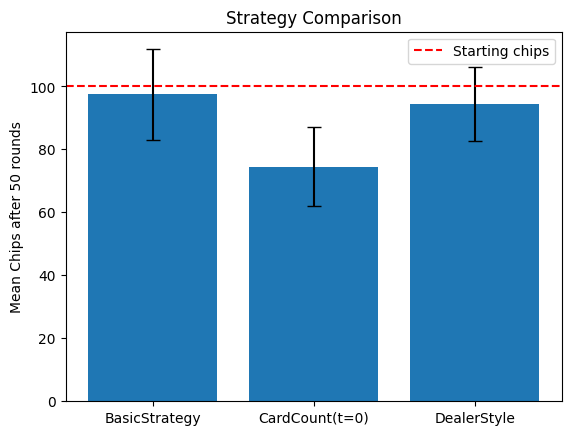

In [15]:
# bar chart comparing mean winnings like the teacher showed
names = list(strategies.keys())
means = [np.mean(strategies[n]) for n in names]
stds = [np.std(strategies[n]) for n in names]

plt.bar(names, means, yerr=stds, capsize=5)
plt.ylabel("Mean Chips after 50 rounds")
plt.title("Strategy Comparison")
plt.axhline(y=starting_chips, color='r', linestyle='--', label="Starting chips")
plt.legend()
plt.show()